# Iris Flower Classification Project

In this project, we use Python to import and classify the Iris flowers dataset using different classification algorithms from scikit-learn. We will display the outputs of each algorithm and compare the accuracy of the models created.

Topics covered:
- Logistic Regression Model
- KNN Classification
- Support Vector Machines
- Decision Trees Classification
- Random Forest Classification
- Naive Bayes Classification

## Section 2/7 - Set Up

Start by setting up the project development environment on your machine. To set up the environment, you need to install the following libraries to be used in the project code:

- NumPy
- Matplotlib
- Pandas
- Scikit-learn

Check for the correct installment on your computer from the terminal before proceeding.

You can install any missing libraries by running (uncomment if needed):
```
# !pip install numpy matplotlib pandas scikit-learn
```

In [1]:
# !pip install numpy matplotlib pandas scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 3/7 - Data Import

Use the following URL link to obtain the CSV file of the Iris Plants dataset.

https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv

The dataset columns are not labeled but they are ordered in the following manner:

`'sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class'`

By using the provided URL or a downloaded version of the CSV file above containing the dataset, import the set into a python script code and store it in a pandas data frame structure while assigning the column names in the data frame in the same order as the line above.

In [2]:
# You can use either the URL directly, or the local 'iris.csv' file provided alongside this notebook
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
# url = "iris.csv"  # uncomment to use the local file instead

column_names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']

dataset = pd.read_csv(url, names=column_names)

print(dataset.shape)
dataset.head()

(150, 5)


,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Quick look at the dataset
dataset.describe()

,sepal-length,sepal-width,petal-length,petal-width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Class distribution
dataset.groupby('class').size()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

## Section 4/7 - Split Data

Create a validation dataset by splitting the loaded data into the following:

- 80% training data for preparing the models (X_train and Y_train)
- 20% as validation held back data from the models (X_test and Y_test)

The number of x_columns for this problem is four as we have four different features in our data. Set the random_state to 7.

In [5]:
from sklearn.model_selection import train_test_split

x_columns = 4

array = dataset.values
X = array[:, 0:x_columns]
Y = array[:, x_columns]

validation_size = 0.20
random_state = 7

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=validation_size, random_state=random_state
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
Y_train shape: (120,)
Y_test shape: (30,)


## Section 5/7 - Build and Train Models

Import needed libraries and create SIX different models as follows:

1. Multi_class Logistic Regression model: `LogisticRegression(solver='liblinear', multi_class='ovr')`
2. K Neighbors Classifier model.
3. Decision Tree Classifier.
4. Random Forest Classifier.
5. Support Vector Machines.
6. Gaussian Naive Bayes Classifier.

Place the models in a list. Iterate over the array of created models and train them using the training data split in step 2.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
# Create the list of models: (name, model_object)
# Note: the 'liblinear' solver requires a one-vs-rest scheme to work with multiclass data.
# In newer scikit-learn versions, the 'multi_class' parameter was removed/deprecated, so we
# wrap LogisticRegression(solver='liblinear') in OneVsRestClassifier to achieve the same
# one-vs-rest (OvR) behavior in a way that works across scikit-learn versions.
log_reg_model = OneVsRestClassifier(LogisticRegression(solver='liblinear'))

models = []
models.append(('Logistic Regression', log_reg_model))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Decision Tree', DecisionTreeClassifier()))
models.append(('Random Forest', RandomForestClassifier()))
models.append(('SVM', SVC()))
models.append(('Naive Bayes', GaussianNB()))

# Train each model on the training data
for name, model in models:
    model.fit(X_train, Y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
KNN trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
Naive Bayes trained successfully.


## Section 6/7 - Compare Output

Compare the predicted and actual output of each of the models by building the confusion matrices of each model and observe the difference.

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

predictions = {}

for name, model in models:
    Y_pred = model.predict(X_test)
    predictions[name] = Y_pred
    print(f"===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, Y_pred))
    print("\nClassification Report:")
    print(classification_report(Y_test, Y_pred))
    print("\n")

===== Logistic Regression =====
Confusion Matrix:
[[ 7  0  0]
 [ 0  7  5]
 [ 0  1 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.88      0.58      0.70        12
 Iris-virginica       0.67      0.91      0.77        11

       accuracy                           0.80        30
      macro avg       0.85      0.83      0.82        30
   weighted avg       0.83      0.80      0.80        30



===== KNN =====
Confusion Matrix:
[[ 7  0  0]
 [ 0 11  1]
 [ 0  2  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.85      0.92      0.88        12
 Iris-virginica       0.90      0.82      0.86        11

       accuracy                           0.90        30
      macro avg       0.92      0.91      0.91        30
   weighted avg       0.90      0.90      0.90

## Section 7/7 - Compare Accuracy and Plot

Calculate and print the accuracy of each of the models and plot the difference in a matplotlib figure titled "Algorithm Comparison"

In [8]:
from sklearn.metrics import accuracy_score

names = []
accuracies = []

for name, model in models:
    acc = accuracy_score(Y_test, predictions[name])
    names.append(name)
    accuracies.append(acc)
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.8000
KNN: 0.9000
Decision Tree: 0.8667
Random Forest: 0.8667
SVM: 0.8667
Naive Bayes: 0.8333


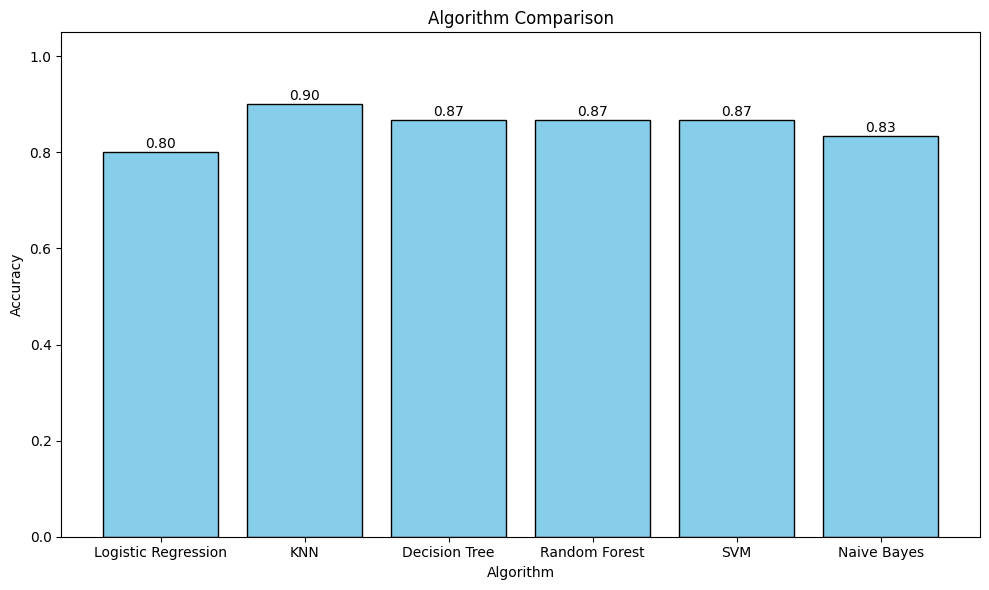

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(names, accuracies, color='skyblue', edgecolor='black')
plt.title("Algorithm Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()